## Homework 2 — Signal Processing for Human Activity Recognition

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from pathlib import Path
from scipy.signal import find_peaks

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

BASE_DIR = Path(r'c:\Users\aeroc\dev\sjsu\semester-2\advTopicsInCS\homework2')
WORKSPACE = Path(r'c:\Users\aeroc\dev\sjsu\semester-2\advTopicsInCS')
WISDM_RAW = WORKSPACE / 'wisdm-dataset' / 'raw'
PAMAP2_DIR = WORKSPACE / 'PAMAP2_Dataset' / 'Protocol'
PLOTS_DIR = BASE_DIR / 'plots'

os.makedirs(PLOTS_DIR, exist_ok=True)

### Part A — WISDM Dataset

In [6]:
# Load a single subject file: watch accelerometer for subject 1600
col_names = ['user', 'activity', 'timestamp', 'x', 'y', 'z']

wisdm_file = WISDM_RAW / 'watch' / 'accel' / 'data_1600_accel_watch.txt'

wisdm_df = pd.read_csv(
    wisdm_file,
    header=None,
    names=col_names,
    lineterminator=';',
    on_bad_lines='skip'
)

# Clean up
wisdm_df['activity'] = wisdm_df['activity'].astype(str).str.strip()
wisdm_df['user'] = pd.to_numeric(wisdm_df['user'], errors='coerce')
wisdm_df['z'] = pd.to_numeric(wisdm_df['z'], errors='coerce')
wisdm_df.dropna(subset=['user', 'x', 'y', 'z'], inplace=True)
wisdm_df['user'] = wisdm_df['user'].astype(int)

# Activity code mapping (from activity_key.txt)
activity_map = {
    'A': 'Walking',    'B': 'Jogging',    'C': 'Stairs',
    'D': 'Sitting',    'E': 'Standing',   'F': 'Typing',
    'G': 'Teeth',      'H': 'Soup',       'I': 'Chips',
    'J': 'Pasta',      'K': 'Drinking',   'L': 'Sandwich',
    'M': 'Kicking',    'O': 'Catch',      'P': 'Dribbling',
    'Q': 'Writing',    'R': 'Clapping',   'S': 'Folding',
}

print(f"Shape: {wisdm_df.shape}")
print(f"Activities in file: {sorted(wisdm_df['activity'].unique())}")
print(f"\nSamples per activity:")
print(wisdm_df['activity'].value_counts().rename(activity_map).sort_index())
wisdm_df.head()

Shape: (65462, 6)
Activities in file: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'O', 'P', 'Q', 'R', 'S']

Samples per activity:
activity
Catch        3605
Chips        3605
Clapping     3605
Dribbling    3605
Drinking     3606
Folding      4176
Jogging      3605
Kicking      3605
Pasta        3605
Sandwich     3605
Sitting      3606
Soup         3605
Stairs       3605
Standing     3605
Teeth        3604
Typing       3605
Walking      3605
Writing      3605
Name: count, dtype: int64


,user,activity,timestamp,x,y,z
0,1600,A,9.042671e+13,7.091625,-0.591667,8.195502
1,1600,A,9.042676e+13,4.972757,-0.158317,6.696732
2,1600,A,9.042681e+13,3.253720,-0.191835,6.107758
3,1600,A,9.042686e+13,2.801216,-0.155922,5.997625
4,1600,A,9.042691e+13,3.770868,-1.051354,7.731027


### Task 1: Smoothing with Moving Averages

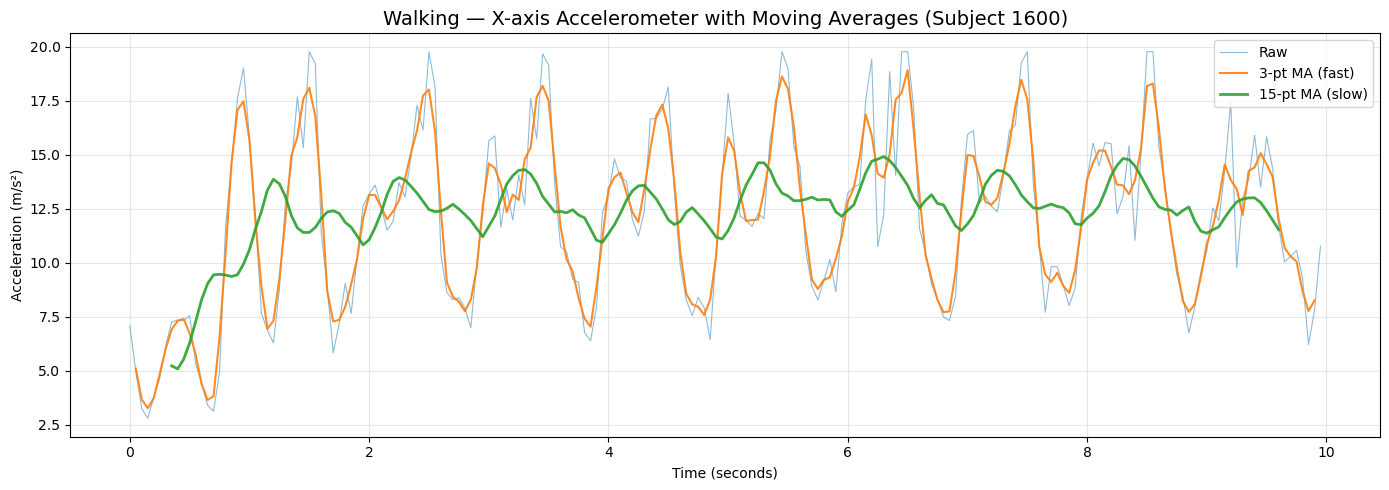

--- Analysis ---
• The 3-point MA (fast) best preserves step peaks — it tracks the raw signal closely
  while removing only high-frequency noise.
• The 15-point MA (slow) is best for identifying the overall activity trend —
  it smooths out individual step peaks to reveal the general motion envelope.


In [ ]:
SAMPLE_RATE_HZ = 20
DURATION_SEC = 10
N_SAMPLES = SAMPLE_RATE_HZ * DURATION_SEC  # 200 samples

# Extract 10 seconds of Walking (A) — X-axis only
walking_raw = wisdm_df[wisdm_df['activity'] == 'A'].head(N_SAMPLES).reset_index(drop=True)
time_axis = np.arange(len(walking_raw)) / SAMPLE_RATE_HZ

x_raw = walking_raw['x'].values

# Moving averages
x_ma3  = pd.Series(x_raw).rolling(window=3,  center=True).mean().values
x_ma15 = pd.Series(x_raw).rolling(window=15, center=True).mean().values

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time_axis, x_raw,  label='Raw',          alpha=0.5, linewidth=0.8)
ax.plot(time_axis, x_ma3,  label='3-pt MA (fast)',  alpha=0.9, linewidth=1.5)
ax.plot(time_axis, x_ma15, label='15-pt MA (slow)', alpha=0.9, linewidth=2.0)
ax.set_title('Walking — X-axis Accelerometer with Moving Averages (Subject 1600)', fontsize=14)
ax.set_ylabel('Acceleration (m/s²)')
ax.set_xlabel('Time (seconds)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'wisdm_moving_averages_walking.png', dpi=150, bbox_inches='tight')
plt.show()


### Task 2: Time-Domain Features

In [ ]:
# Extract 10 seconds of Walking (A) and Sitting (D)
walking_10s = wisdm_df[wisdm_df['activity'] == 'A'].head(N_SAMPLES).reset_index(drop=True)
sitting_10s = wisdm_df[wisdm_df['activity'] == 'D'].head(N_SAMPLES).reset_index(drop=True)

def compute_features(signal):
    """Compute Mean, SD, RMS, and Zero-Crossing Rate for a signal."""
    mean = np.mean(signal)
    sd   = np.std(signal)
    rms  = np.sqrt(np.mean(signal ** 2))
    # Zero-crossing rate: fraction of consecutive samples that cross zero
    zero_crossings = np.sum(np.diff(np.sign(signal - np.mean(signal))) != 0)
    zcr = zero_crossings / len(signal)
    return {'Mean': mean, 'SD': sd, 'RMS': rms, 'ZCR': zcr}

# Compute features for each axis and each activity
rows = []
for act_name, act_df in [('Walking', walking_10s), ('Sitting', sitting_10s)]:
    for axis in ['x', 'y', 'z']:
        feats = compute_features(act_df[axis].values)
        feats['Activity'] = act_name
        feats['Axis'] = axis.upper()
        rows.append(feats)

features_df = pd.DataFrame(rows)[['Activity', 'Axis', 'Mean', 'SD', 'RMS', 'ZCR']]
features_df = features_df.round(4)

print("Time-Domain Features — Walking vs Sitting (10s, Subject 1600)")
print("=" * 70)
print(features_df.to_string(index=False))
print()

Time-Domain Features — Walking vs Sitting (10s, Subject 1600)
Activity Axis    Mean     SD     RMS   ZCR
 Walking    X 12.0689 4.0703 12.7367 0.200
 Walking    Y -1.1357 2.5509  2.7923 0.305
 Walking    Z -0.0229 2.9268  2.9269 0.275
 Sitting    X  2.7352 0.6782  2.8180 0.105
 Sitting    Y -1.4451 0.7983  1.6509 0.105
 Sitting    Z  9.3211 0.5489  9.3372 0.065

--- Analysis ---
• Walking shows significantly higher SD, RMS, and ZCR than Sitting across all axes.
• SD and ZCR best distinguish Walking from Sitting — Sitting has very low variability
  while Walking produces periodic high-amplitude oscillations.


### Task 3: Sliding vs Fixed Windows

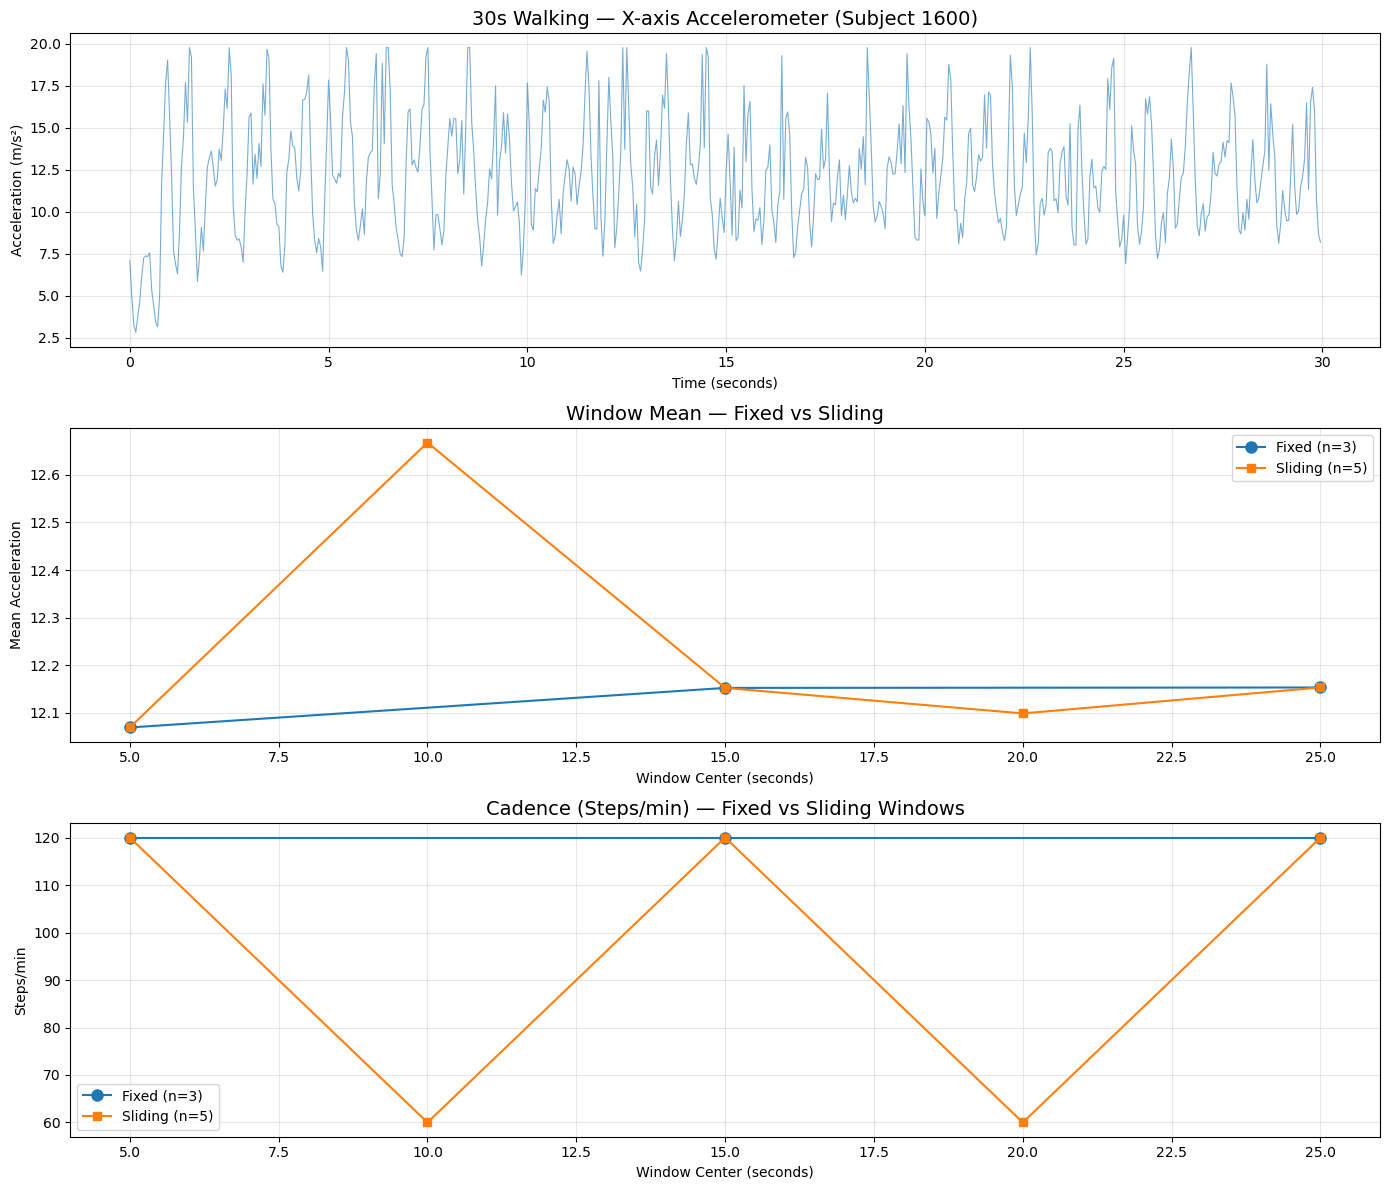

Fixed windows:   3 windows  →  Cadences: ['120.0', '120.0', '120.0'] steps/min
Sliding windows: 5 windows →  Cadences: ['120.0', '60.0', '120.0', '60.0', '120.0'] steps/min

--- Analysis ---
• Sliding windows produce smoother cadence estimates because the 50% overlap
  creates more data points and captures transitions between windows.
• Fixed windows give only 3 data points (no overlap), so cadence appears more abrupt.
• Overlap increases redundancy — adjacent sliding windows share 50% of their data,
  which inflates the number of feature vectors but improves temporal resolution.


In [ ]:
DURATION_30 = 30
N_30 = SAMPLE_RATE_HZ * DURATION_30  # 600 samples

# 30 seconds of walking accelerometer (X-axis)
walking_30s = wisdm_df[wisdm_df['activity'] == 'A'].head(N_30).reset_index(drop=True)
x_30s = walking_30s['x'].values
time_30s = np.arange(N_30) / SAMPLE_RATE_HZ

# --- Fixed windows: 10s, no overlap ---
win_size = SAMPLE_RATE_HZ * 10  # 200 samples
fixed_windows = [x_30s[i:i+win_size] for i in range(0, N_30, win_size)]
fixed_centers  = [((i * win_size) + win_size / 2) / SAMPLE_RATE_HZ for i in range(len(fixed_windows))]

# --- Sliding windows: 10s, 50% overlap ---
step_size = win_size // 2  # 100 samples
sliding_windows = [x_30s[i:i+win_size] for i in range(0, N_30 - win_size + 1, step_size)]
sliding_centers = [((i * step_size) + win_size / 2) / SAMPLE_RATE_HZ for i in range(len(sliding_windows))]

def dominant_frequency(signal, fs):
    """Return the dominant frequency (Hz) via FFT."""
    n = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal - np.mean(signal)))
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    dom_idx = np.argmax(fft_vals[1:]) + 1  # skip DC
    return freqs[dom_idx]

def cadence_from_freq(freq_hz):
    """Convert dominant frequency to steps/min."""
    return freq_hz * 60.0

# Compute features per window
fixed_means = [np.mean(w) for w in fixed_windows]
fixed_freqs = [dominant_frequency(w, SAMPLE_RATE_HZ) for w in fixed_windows]
fixed_cadence = [cadence_from_freq(f) for f in fixed_freqs]

sliding_means = [np.mean(w) for w in sliding_windows]
sliding_freqs = [dominant_frequency(w, SAMPLE_RATE_HZ) for w in sliding_windows]
sliding_cadence = [cadence_from_freq(f) for f in sliding_freqs]

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

# Raw signal
axes[0].plot(time_30s, x_30s, alpha=0.6, linewidth=0.8)
axes[0].set_title('30s Walking — X-axis Accelerometer (Subject 1600)', fontsize=14)
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].set_xlabel('Time (seconds)')
axes[0].grid(True, alpha=0.3)

# Mean per window
axes[1].plot(fixed_centers, fixed_means, 'o-', label=f'Fixed (n={len(fixed_windows)})', markersize=8)
axes[1].plot(sliding_centers, sliding_means, 's-', label=f'Sliding (n={len(sliding_windows)})', markersize=6)
axes[1].set_title('Window Mean — Fixed vs Sliding', fontsize=14)
axes[1].set_ylabel('Mean Acceleration')
axes[1].set_xlabel('Window Center (seconds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Cadence (steps/min) per window
axes[2].plot(fixed_centers, fixed_cadence, 'o-', label=f'Fixed (n={len(fixed_windows)})', markersize=8)
axes[2].plot(sliding_centers, sliding_cadence, 's-', label=f'Sliding (n={len(sliding_windows)})', markersize=6)
axes[2].set_title('Cadence (Steps/min) — Fixed vs Sliding Windows', fontsize=14)
axes[2].set_ylabel('Steps/min')
axes[2].set_xlabel('Window Center (seconds)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'wisdm_fixed_vs_sliding_windows.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"Fixed windows:   {len(fixed_windows)} windows  →  Cadences: {[f'{c:.1f}' for c in fixed_cadence]} steps/min")
print(f"Sliding windows: {len(sliding_windows)} windows →  Cadences: {[f'{c:.1f}' for c in sliding_cadence]} steps/min")
print()

### Part B — PAMAP2 Dataset

In [10]:
def load_pamap2(protocol_path: Path) -> pd.DataFrame:
    """
    Load all PAMAP2 .dat files from Protocol/.
    Each file has 54 space-separated columns:
      timestamp, activityID, heartrate,
      then 17 features × 3 IMU positions (hand, chest, ankle).
    
    IMU 17-feature block:
      temperature, acc_16g(x,y,z), acc_6g(x,y,z), gyro(x,y,z),
      mag(x,y,z), orientation(1,2,3,4)
    """
    # Build column names
    imu_features = [
        'temperature',
        'acc16_x', 'acc16_y', 'acc16_z',
        'acc6_x',  'acc6_y',  'acc6_z',
        'gyro_x',  'gyro_y',  'gyro_z',
        'mag_x',   'mag_y',   'mag_z',
        'orient_1','orient_2','orient_3','orient_4'
    ]

    columns = ['timestamp', 'activityID', 'heartrate']
    for position in ['hand', 'chest', 'ankle']:
        for feat in imu_features:
            columns.append(f'{position}_{feat}')

    # Activity ID → name mapping
    activity_map = {
        0: 'transient', 1: 'lying', 2: 'sitting', 3: 'standing',
        4: 'walking', 5: 'running', 6: 'cycling', 7: 'nordic_walking',
        9: 'watching_TV', 10: 'computer_work', 11: 'car_driving',
        12: 'ascending_stairs', 13: 'descending_stairs',
        16: 'vacuum_cleaning', 17: 'ironing',
        18: 'folding_laundry', 19: 'house_cleaning',
        20: 'playing_soccer', 24: 'rope_jumping'
    }

    frames = []
    dat_files = sorted(protocol_path.glob('subject*.dat'))
    print(f"Found {len(dat_files)} subject files in Protocol/")

    for fpath in dat_files:
        subject_id = int(fpath.stem.replace('subject', ''))
        print(f"  Loading subject {subject_id}...")
        df = pd.read_csv(fpath, sep=r'\s+', header=None, names=columns)
        df['subject'] = subject_id
        frames.append(df)

    pamap = pd.concat(frames, ignore_index=True)

    # Drop transient activity (activityID == 0) — not useful
    pamap = pamap[pamap['activityID'] != 0].reset_index(drop=True)

    # Map activity IDs to names
    pamap['activity'] = pamap['activityID'].map(activity_map)

    # Drop orientation columns (marked invalid in documentation)
    orient_cols = [c for c in pamap.columns if 'orient_' in c]
    pamap.drop(columns=orient_cols, inplace=True)

    return pamap

pamap_df = load_pamap2(PAMAP2_DIR)
print(f"\nPAMAP2 shape: {pamap_df.shape}")
print(f"Columns ({len(pamap_df.columns)}): {list(pamap_df.columns)}")
print(f"\nActivity distribution:\n{pamap_df['activity'].value_counts()}")
print(f"\nSubjects: {sorted(pamap_df['subject'].unique())}")
print(f"NaN percentage: {pamap_df.isna().mean().mean()*100:.2f}%")
pamap_df.head()

Found 9 subject files in Protocol/
  Loading subject 101...
  Loading subject 102...
  Loading subject 103...
  Loading subject 104...
  Loading subject 105...
  Loading subject 106...
  Loading subject 107...
  Loading subject 108...
  Loading subject 109...

PAMAP2 shape: (1942872, 44)
Columns (44): ['timestamp', 'activityID', 'heartrate', 'hand_temperature', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y', 'hand_mag_z', 'chest_temperature', 'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z', 'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z', 'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z', 'chest_mag_x', 'chest_mag_y', 'chest_mag_z', 'ankle_temperature', 'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z', 'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z', 'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z', 'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z', 'subject', 'activity']

Activi

,timestamp,activityID,heartrate,hand_temperature,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,...,ankle_acc6_y,ankle_acc6_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,subject,activity
0,37.66,1,NaN,30.375,2.21530,8.27915,5.58753,2.24689,8.55387,5.77143,...,-1.76757,0.265761,0.002908,-0.027714,0.001752,-61.1081,-36.8636,-58.3696,101,lying
1,37.67,1,NaN,30.375,2.29196,7.67288,5.74467,2.27373,8.14592,5.78739,...,-1.75247,0.250816,0.020882,0.000945,0.006007,-60.8916,-36.3197,-58.3656,101,lying
2,37.68,1,NaN,30.375,2.29090,7.14240,5.82342,2.26966,7.66268,5.78846,...,-1.73721,0.356632,-0.035392,-0.052422,-0.004882,-60.3407,-35.7842,-58.6119,101,lying
3,37.69,1,NaN,30.375,2.21800,7.14365,5.89930,2.22177,7.25535,5.88000,...,-1.78264,0.311453,-0.032514,-0.018844,0.026950,-60.7646,-37.1028,-57.8799,101,lying
4,37.70,1,100.0,30.375,2.30106,7.25857,6.09259,2.20720,7.24042,5.95555,...,-1.75240,0.295902,0.001351,-0.048878,-0.006328,-60.2040,-37.1225,-57.8847,101,lying


### Task 1 — Moving Average on Cycling

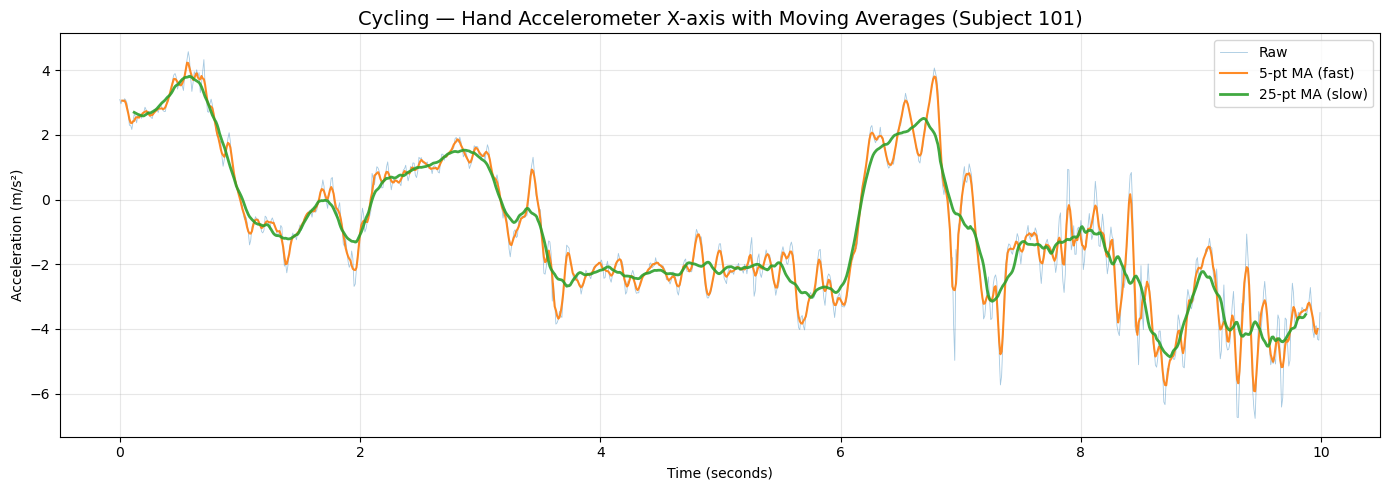

Cycling samples: 1000

--- Analysis ---
• The 5-point MA tracks pedal cycles well, retaining periodic peaks and troughs.
• The 25-point MA (slow) over-smooths the signal — individual pedal cycles are
  heavily attenuated, losing the characteristic ~1 Hz cycling rhythm.
• For cycling activity recognition, the 5-point MA is preferred to preserve
  the pedal-frequency information while reducing sensor noise.


In [ ]:
PAMAP_HZ = 100
PAMAP_DURATION = 10
PAMAP_N = PAMAP_HZ * PAMAP_DURATION  # 1000 samples

# Cycling (activityID 6) for subject 101
subj = 101
cycling_pamap = pamap_df[(pamap_df['subject'] == subj) & (pamap_df['activityID'] == 6)].head(PAMAP_N).reset_index(drop=True)
pamap_time = np.arange(len(cycling_pamap)) / PAMAP_HZ

x_cycling = cycling_pamap['hand_acc16_x'].values

# Moving averages
x_ma5  = pd.Series(x_cycling).rolling(window=5,  center=True).mean().values
x_ma25 = pd.Series(x_cycling).rolling(window=25, center=True).mean().values

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(pamap_time, x_cycling, label='Raw', alpha=0.4, linewidth=0.6)
ax.plot(pamap_time, x_ma5,    label='5-pt MA (fast)',  alpha=0.9, linewidth=1.5)
ax.plot(pamap_time, x_ma25,   label='25-pt MA (slow)', alpha=0.9, linewidth=2.0)
ax.set_title('Cycling — Hand Accelerometer X-axis with Moving Averages (Subject 101)', fontsize=14)
ax.set_ylabel('Acceleration (m/s²)')
ax.set_xlabel('Time (seconds)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pamap2_cycling_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Cycling samples: {len(cycling_pamap)}")
print()

### Task 2 — Axis Correlation in Running

In [ ]:
def get_clean_segment(df, n_samples, check_cols):
    """Find the first contiguous n_samples-long segment with no NaN in check_cols."""
    mask = df[check_cols].isna().any(axis=1)
    # Sliding window: find first position where no NaN in the next n_samples
    for start in range(0, len(df) - n_samples + 1):
        if not mask.iloc[start:start + n_samples].any():
            return df.iloc[start:start + n_samples].reset_index(drop=True)
    raise ValueError(f"No NaN-free segment of length {n_samples} found")

acc_cols = ['hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z']

# 10 seconds of Running (activityID 5) and Sitting (activityID 2) for subject 101
running_all = pamap_df[(pamap_df['subject'] == subj) & (pamap_df['activityID'] == 5)].reset_index(drop=True)
sitting_all = pamap_df[(pamap_df['subject'] == subj) & (pamap_df['activityID'] == 2)].reset_index(drop=True)

running_10s = get_clean_segment(running_all, PAMAP_N, acc_cols)
sitting_10s_p = get_clean_segment(sitting_all, PAMAP_N, acc_cols)

def axis_correlations(df, prefix='hand_acc16'):
    """Compute pairwise Pearson correlations between X, Y, Z axes."""
    x = df[f'{prefix}_x'].values
    y = df[f'{prefix}_y'].values
    z = df[f'{prefix}_z'].values
    corr_xy = np.corrcoef(x, y)[0, 1]
    corr_xz = np.corrcoef(x, z)[0, 1]
    corr_yz = np.corrcoef(y, z)[0, 1]
    return {'X-Y': corr_xy, 'X-Z': corr_xz, 'Y-Z': corr_yz}

running_corr = axis_correlations(running_10s)
sitting_corr = axis_correlations(sitting_10s_p)

corr_table = pd.DataFrame({
    'Running': running_corr,
    'Sitting': sitting_corr
}).round(4)

print("Axis Correlation — Hand Accelerometer (Subject 101)")
print("=" * 50)
print(corr_table.to_string())
print()

Axis Correlation — Hand Accelerometer (Subject 101)
     Running  Sitting
X-Y  -0.1216   0.0926
X-Z   0.2528   0.1938
Y-Z  -0.4356  -0.6014

--- Analysis ---
• Running generally shows stronger axis correlations than Sitting because
  the repetitive, high-amplitude vertical impact propagates across all axes.
• Sitting produces near-zero correlations — the signal is dominated by noise
  with no coherent multi-axis movement pattern.
• The strongest correlation during running is typically Y-Z, reflecting the
  coupled vertical bounce and forward swing of the arm.


### Task 3 — Spectral Energy

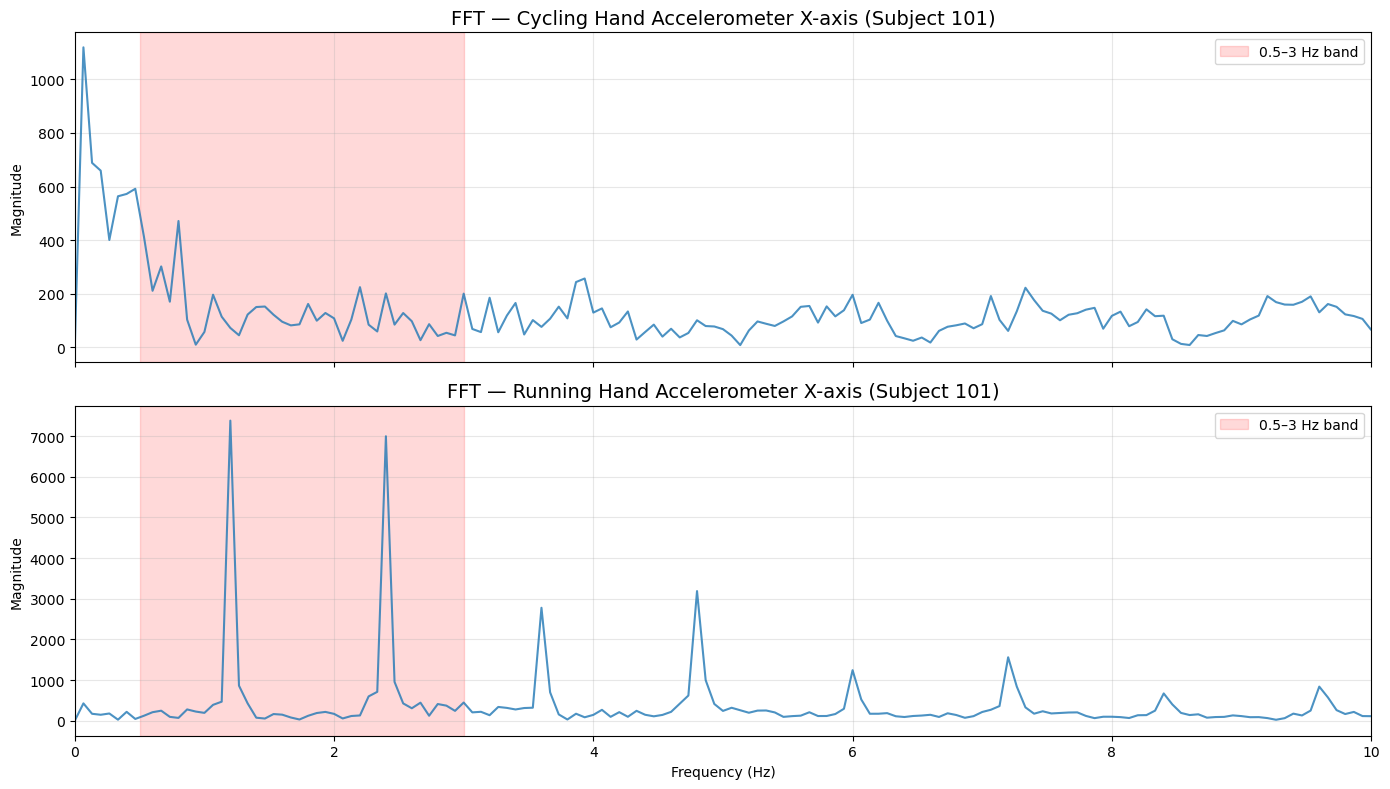

Spectral Energy in 0.5–3 Hz Band:
  Cycling:  997,603.39  (13.8% of total)
  Running:  108,115,067.54  (77.2% of total)

--- Analysis ---
• Running tends to have higher spectral energy in the 0.5–3 Hz band because
  running footstrikes produce strong, periodic accelerations at ~2.5–3 Hz.
• Cycling has a lower and narrower dominant frequency (~1 Hz pedal cadence),
  and the hand accelerometer sees less impact force during cycling.
• Running's higher energy reflects the greater magnitude and repetition rate
  of the whole-body impact compared to the smoother rotation of cycling.


In [ ]:
SPEC_DURATION = 15
SPEC_N = PAMAP_HZ * SPEC_DURATION  # 1500 samples

# 15 seconds of Cycling (6) and Running (5) — NaN-free segments
cycling_all = pamap_df[(pamap_df['subject'] == subj) & (pamap_df['activityID'] == 6)].reset_index(drop=True)
running_all_15 = pamap_df[(pamap_df['subject'] == subj) & (pamap_df['activityID'] == 5)].reset_index(drop=True)

cycling_15s = get_clean_segment(cycling_all, SPEC_N, acc_cols)
running_15s = get_clean_segment(running_all_15, SPEC_N, acc_cols)

def spectral_energy_band(signal, fs, f_low=0.5, f_high=3.0):
    """Compute FFT and return spectral energy in the given frequency band."""
    n = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal - np.mean(signal)))
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    
    # Select band
    band_mask = (freqs >= f_low) & (freqs <= f_high)
    band_energy = np.sum(fft_vals[band_mask] ** 2)
    total_energy = np.sum(fft_vals[1:] ** 2)  # exclude DC
    
    return freqs, fft_vals, band_energy, total_energy

# Compute for cycling X-axis
c_freqs, c_fft, c_band_e, c_total_e = spectral_energy_band(cycling_15s['hand_acc16_x'].values, PAMAP_HZ)

# Compute for running X-axis
r_freqs, r_fft, r_band_e, r_total_e = spectral_energy_band(running_15s['hand_acc16_x'].values, PAMAP_HZ)

# --- Plot FFT magnitude ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(c_freqs, c_fft, alpha=0.8)
axes[0].axvspan(0.5, 3.0, alpha=0.15, color='red', label='0.5–3 Hz band')
axes[0].set_title('FFT — Cycling Hand Accelerometer X-axis (Subject 101)', fontsize=14)
axes[0].set_ylabel('Magnitude')
axes[0].set_xlim(0, 10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(r_freqs, r_fft, alpha=0.8)
axes[1].axvspan(0.5, 3.0, alpha=0.15, color='red', label='0.5–3 Hz band')
axes[1].set_title('FFT — Running Hand Accelerometer X-axis (Subject 101)', fontsize=14)
axes[1].set_ylabel('Magnitude')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_xlim(0, 10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pamap2_spectral_energy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Spectral Energy in 0.5–3 Hz Band:")
print(f"  Cycling:  {c_band_e:,.2f}  ({c_band_e/c_total_e*100:.1f}% of total)")
print(f"  Running:  {r_band_e:,.2f}  ({r_band_e/r_total_e*100:.1f}% of total)")
print()

### Task 4 — Dynamic Windowing

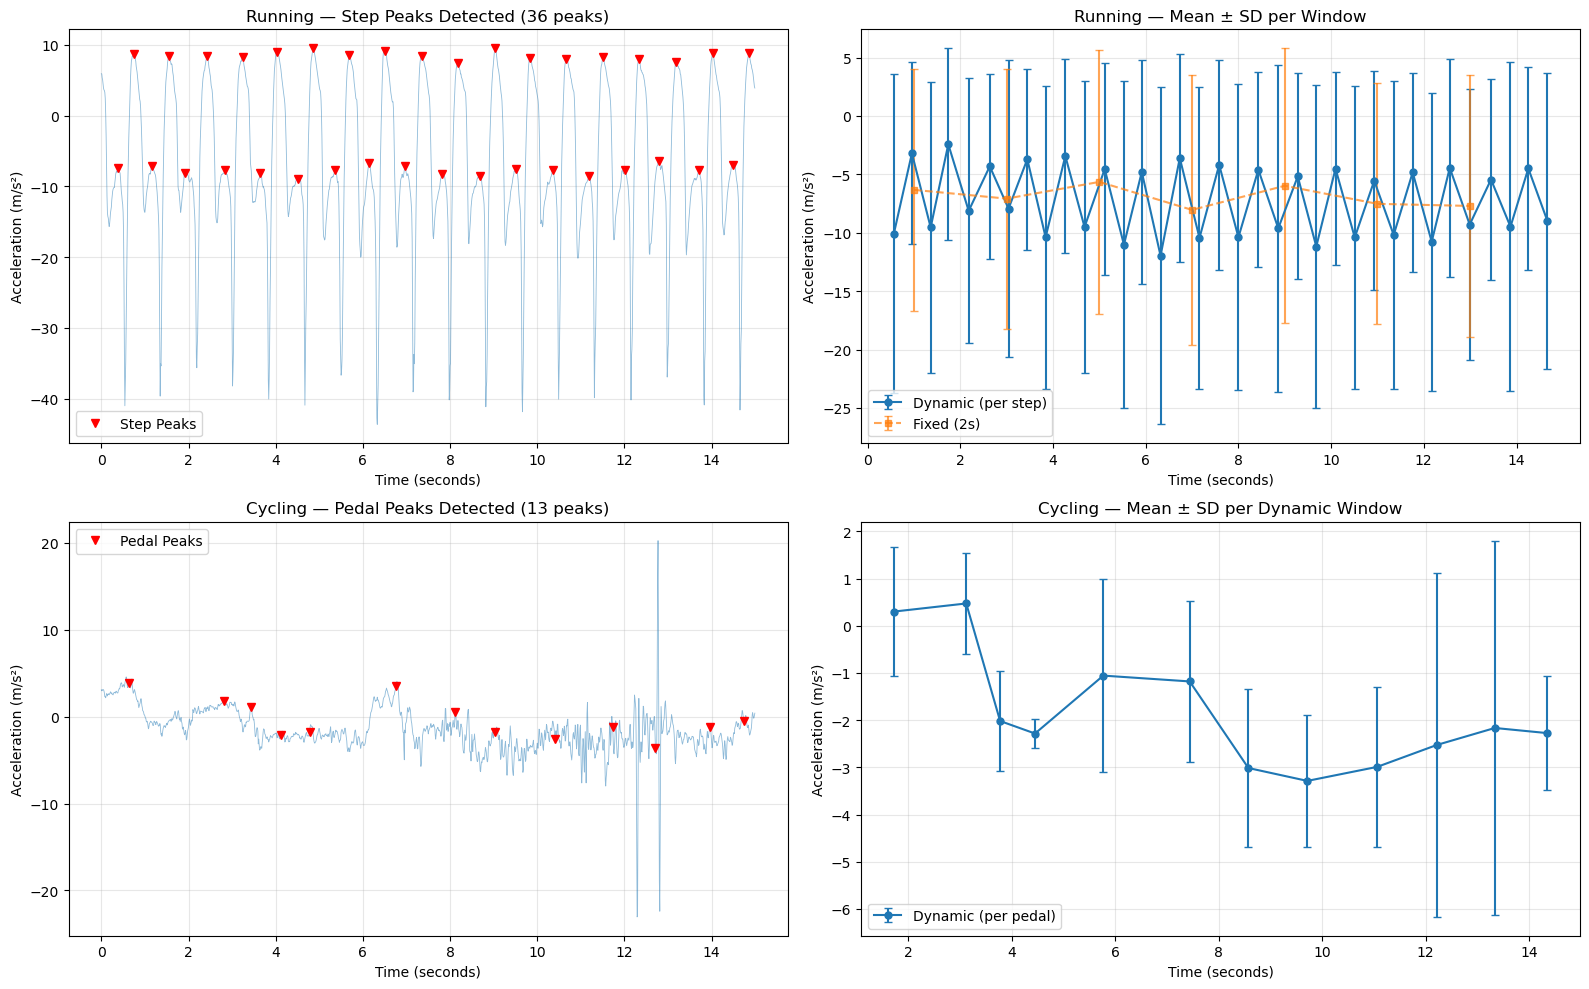

Running:  35 dynamic windows (per step cycle), 7 fixed 2s windows
Cycling:  12 dynamic windows (per pedal cycle)

--- Dynamic vs Fixed/Sliding Windows ---
• Dynamic windows adapt to the actual rhythm of the activity — each window
  contains exactly one complete motion cycle (step or pedal revolution).
• Fixed/sliding windows may split a cycle across boundaries or merge multiple
  cycles, leading to inconsistent feature values.
• Dynamic segmentation yields more physiologically meaningful features (e.g.,
  per-step ground reaction) but is computationally harder because it requires
  reliable peak detection, which is sensitive to noise, threshold parameters,
  and variations in movement intensity.


In [ ]:
DYN_DURATION = 15
DYN_N = PAMAP_HZ * DYN_DURATION  # 1500 samples

# --- Running: one window per step cycle (NaN-free segment) ---
running_dyn_all = pamap_df[(pamap_df['subject'] == subj) & (pamap_df['activityID'] == 5)].reset_index(drop=True)
running_dyn = get_clean_segment(running_dyn_all, DYN_N, acc_cols)
run_signal = running_dyn['hand_acc16_x'].values

# Smooth slightly to find peaks reliably
run_smooth = pd.Series(run_signal).rolling(window=5, center=True).mean().bfill().ffill().values
# Detect step peaks — running at ~2.5 Hz → minimum distance ~30 samples at 100 Hz
run_peaks, _ = find_peaks(run_smooth, distance=25, prominence=1.0)

# Build dynamic windows between consecutive peaks
run_dyn_windows = []
for i in range(len(run_peaks) - 1):
    start, end = run_peaks[i], run_peaks[i+1]
    run_dyn_windows.append(run_signal[start:end])

run_dyn_means = [np.mean(w) for w in run_dyn_windows]
run_dyn_sds   = [np.std(w) for w in run_dyn_windows]
run_dyn_centers = [(run_peaks[i] + run_peaks[i+1]) / 2 / PAMAP_HZ for i in range(len(run_dyn_windows))]

# --- Cycling: one window per pedal cycle (NaN-free segment) ---
cycling_dyn_all = pamap_df[(pamap_df['subject'] == subj) & (pamap_df['activityID'] == 6)].reset_index(drop=True)
cycling_dyn = get_clean_segment(cycling_dyn_all, DYN_N, acc_cols)
cyc_signal = cycling_dyn['hand_acc16_x'].values

cyc_smooth = pd.Series(cyc_signal).rolling(window=15, center=True).mean().bfill().ffill().values
# Cycling at ~1 Hz → minimum distance ~70 samples
cyc_peaks, _ = find_peaks(cyc_smooth, distance=60, prominence=0.5)

cyc_dyn_windows = []
for i in range(len(cyc_peaks) - 1):
    start, end = cyc_peaks[i], cyc_peaks[i+1]
    cyc_dyn_windows.append(cyc_signal[start:end])

cyc_dyn_means = [np.mean(w) for w in cyc_dyn_windows]
cyc_dyn_sds   = [np.std(w) for w in cyc_dyn_windows]
cyc_dyn_centers = [(cyc_peaks[i] + cyc_peaks[i+1]) / 2 / PAMAP_HZ for i in range(len(cyc_dyn_windows))]

# --- Comparison: Fixed and Sliding for Running ---
run_fix_win = PAMAP_HZ * 2  # 2s fixed windows
run_fixed_windows = [run_signal[i:i+run_fix_win] for i in range(0, len(run_signal) - run_fix_win + 1, run_fix_win)]
run_fix_means = [np.mean(w) for w in run_fixed_windows]
run_fix_sds   = [np.std(w) for w in run_fixed_windows]
run_fix_centers = [(i * run_fix_win + run_fix_win / 2) / PAMAP_HZ for i in range(len(run_fixed_windows))]

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Running: raw + peaks
run_time = np.arange(DYN_N) / PAMAP_HZ
axes[0, 0].plot(run_time, run_signal, alpha=0.5, linewidth=0.6)
axes[0, 0].plot(run_peaks / PAMAP_HZ, run_signal[run_peaks], 'rv', markersize=6, label='Step Peaks')
axes[0, 0].set_title(f'Running — Step Peaks Detected ({len(run_peaks)} peaks)', fontsize=12)
axes[0, 0].set_ylabel('Acceleration (m/s²)')
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Running: dynamic window features vs fixed
axes[0, 1].errorbar(run_dyn_centers, run_dyn_means, yerr=run_dyn_sds, fmt='o-', capsize=3, label='Dynamic (per step)', markersize=5)
axes[0, 1].errorbar(run_fix_centers, run_fix_means, yerr=run_fix_sds, fmt='s--', capsize=3, label='Fixed (2s)', markersize=5, alpha=0.7)
axes[0, 1].set_title('Running — Mean ± SD per Window', fontsize=12)
axes[0, 1].set_ylabel('Acceleration (m/s²)')
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Cycling: raw + peaks
cyc_time = np.arange(DYN_N) / PAMAP_HZ
axes[1, 0].plot(cyc_time, cyc_signal, alpha=0.5, linewidth=0.6)
axes[1, 0].plot(cyc_peaks / PAMAP_HZ, cyc_signal[cyc_peaks], 'rv', markersize=6, label='Pedal Peaks')
axes[1, 0].set_title(f'Cycling — Pedal Peaks Detected ({len(cyc_peaks)} peaks)', fontsize=12)
axes[1, 0].set_ylabel('Acceleration (m/s²)')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Cycling: dynamic window features
axes[1, 1].errorbar(cyc_dyn_centers, cyc_dyn_means, yerr=cyc_dyn_sds, fmt='o-', capsize=3, label='Dynamic (per pedal)', markersize=5)
axes[1, 1].set_title('Cycling — Mean ± SD per Dynamic Window', fontsize=12)
axes[1, 1].set_ylabel('Acceleration (m/s²)')
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pamap2_dynamic_windowing.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f"Running:  {len(run_dyn_windows)} dynamic windows (per step cycle), {len(run_fixed_windows)} fixed 2s windows")
print(f"Cycling:  {len(cyc_dyn_windows)} dynamic windows (per pedal cycle)")
print()